In [454]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, softmax
from sklearn.preprocessing import RobustScaler
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [455]:
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata"
time_col = 'ENGINE_RUN_TINE ()'

files = [file for file in os.listdir(path) if file.endswith('.csv')]

df_list = []
for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(f'{path}/{file}', index_col=False)
        df['drive_id'] = file
        df_list.append(df)


print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


# %%
def remove_zero_variance_columns(df: pd.DataFrame, exclude_cols: list[str] = None) -> pd.DataFrame:
    """
    Compute std of each std-computable column (numeric only)
    """
    if exclude_cols is None:
        exclude_cols = []
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    cols_to_check = [col for col in numeric_cols if col not in exclude_cols]
  
    std_df = df[cols_to_check].std()
    zero_variance_cols = std_df[std_df == 0].index.tolist()
  
    print(f'{len(zero_variance_cols)} columns with zero variance: {zero_variance_cols}')
  
    if len(zero_variance_cols) > 0:
        df = df.drop(columns=zero_variance_cols)
  
    return df


# %%
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame, time_col: str, id_cols: list[str] = None) -> pd.DataFrame:
    """
    Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
    This preserves the overall statistics while removing duplicate entries.
    
    Note: The time column itself is not averaged (it becomes the group key).
    Only numeric columns are averaged when multiple rows share the same timestamp.
    """
    if id_cols is None:
        id_cols = []
    
    existing_id_cols = [col for col in id_cols if col in df.columns]
    
    group_cols = [time_col] + existing_id_cols
    
    agg_dict = {}
    for col in df.columns:
        if col not in group_cols:
            if pd.api.types.is_numeric_dtype(df[col]):
                agg_dict[col] = 'mean'
            else:
                agg_dict[col] = 'first'
  
    df_clean = df.groupby(group_cols, as_index=False).agg(agg_dict)
  
    return df_clean


# %%
def downsample(df, time_col, source_file_col, downsample_factor=2):
    result_dfs = []
    
    for source_file in df[source_file_col].unique():
        file_df = df[df[source_file_col] == source_file].copy()
        
        if len(file_df) < downsample_factor * 2:
            continue
        
        file_df = file_df.sort_values(time_col).reset_index(drop=True)
        
        # Simple decimation without pre-smoothing
        downsampled = file_df.iloc[::downsample_factor].copy()
        downsampled[time_col] = np.arange(len(downsampled)) * downsample_factor
        
        result_dfs.append(downsampled.reset_index(drop=True))
    
    return pd.concat(result_dfs, ignore_index=True)


# %%
def filter_long_drives(df, id_col='drive_id', min_length=608):
    """Keep only drives long enough for your context window"""
    drive_lengths = df.groupby(id_col).size()
    valid_drives = drive_lengths[drive_lengths >= min_length].index
    
    print(f"Keeping {len(valid_drives)}/{df[id_col].nunique()} drives")
    print(f"Dropped {len(df) - df[df[id_col].isin(valid_drives)].shape[0]} timesteps")
    
    return df[df[id_col].isin(valid_drives)].reset_index(drop=True)


# %%
# Combine all dataframes
data = pd.concat(df_list, ignore_index=True)


# Clean up
print(f"Total samples: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")


# remove some useless columns
data = data.drop(columns=['WARM_UPS_SINCE_CODES_CLEARED ()', 'TIME_SINCE_TROUBLE_CODES_CLEARED ()'])


data = mean_fill_missing_timestamps_and_remove_duplicates(data, time_col=time_col, id_cols=["drive_id"])
data = remove_zero_variance_columns(data, exclude_cols=["drive_id"])
data = downsample(
    data,
    time_col=time_col,
    source_file_col='drive_id',
    downsample_factor=1
)
data.drop(columns=["drive_id"], inplace=True)


129 files loaded out of 129
Total samples: 304,299
Unique drives: 129
3 columns with zero variance: ['FUEL_AIR_COMMANDED_EQUIV_RATIO ()', 'TIME_RUN_WITH_MIL_ON ()', 'DISTANCE_TRAVELED_WITH_MIL_ON ()']


In [456]:
import sys
sys.path.insert(0, '/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/anomaly-detection')

train_ratio = 0.7
val_ratio = 0.15

train_size = int(len(data) * train_ratio)
val_size = int(len(data) * val_ratio)

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]


scaler = RobustScaler()
train_data_scaled = scaler.fit_transform(train_data)
val_data_scaled = scaler.transform(val_data)
test_data_scaled = scaler.transform(test_data)

train_data_clean = np.clip(train_data_scaled, -10, 10)
val_data_scaled = np.clip(val_data_scaled, -10, 10)  
test_data_scaled = np.clip(test_data_scaled, -10, 10)


print(f"Train: {train_data_scaled.shape}")
print(f"Val: {val_data_scaled.shape}")
print(f"Test: {test_data_scaled.shape}")

def create_sliding_windows(data, window_size=5):
    """
    Create sliding windows for time series
    X: [num_samples, num_features, window_size] - input windows
    y: [num_samples, num_features] - target values (next timestep)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size].T)  # [num_features, window_size]
        y.append(data[i+window_size])      # [num_features]
    return np.array(X), np.array(y)

window_size = 5
X_train, y_train = create_sliding_windows(train_data_clean, window_size)
X_val, y_val = create_sliding_windows(val_data_scaled, window_size)
X_test, y_test = create_sliding_windows(test_data_scaled, window_size)

print(f"X_train shape: {X_train.shape}")  # [samples, num_features, window_size]
print(f"y_train shape: {y_train.shape}")  # [samples, num_features]

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Train: (57684, 22)
Val: (12361, 22)
Test: (12362, 22)
X_train shape: (57679, 22, 5)
y_train shape: (57679, 22)
Number of training batches: 902
Number of validation batches: 194
Number of test batches: 194


In [457]:
class GraphAttentionLayer(MessagePassing):
    """
    Numerically stable Graph Attention Layer
    """
    def __init__(self, in_dim, out_dim, embed_dim):
        super().__init__(aggr='add')
        
        # Feature transformation
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        
        # Attention mechanism
        self.att = nn.Linear(2 * (embed_dim + out_dim), 1, bias=False)
        
        self.embed_dim = embed_dim
        self.out_dim = out_dim
        self.leaky_relu = nn.LeakyReLU(0.2)
        
        # ✅ CRITICAL: Initialize weights properly
        nn.init.xavier_normal_(self.W.weight, gain=0.1)
        nn.init.xavier_normal_(self.att.weight, gain=0.1)
    
    def forward(self, x, edge_index, embeddings):
        """
        x: [num_nodes, in_dim]
        edge_index: [2, num_edges]
        embeddings: [num_nodes, embed_dim]
        """
        # ✅ Check for NaN in inputs
        if torch.isnan(x).any():
            x = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0)
        
        if torch.isnan(embeddings).any():
            embeddings = torch.nan_to_num(embeddings, nan=0.0, posinf=1.0, neginf=-1.0)
        
        # Transform features
        x_transformed = self.W(x)
        
        # ✅ Check after transformation
        if torch.isnan(x_transformed).any():
            x_transformed = torch.nan_to_num(x_transformed, nan=0.0)
        
        # Concatenate with embeddings
        x_with_embed = torch.cat([embeddings, x_transformed], dim=1)
        
        # Message passing
        out = self.propagate(edge_index, x=x_with_embed, size=None)
        
        return F.relu(out)
    
    def message(self, x_i, x_j, edge_index_i, size_i):
        """
        ✅ FIXED: Added size_i parameter (critical for batched graphs!)
        """
        # Concatenate source and target
        x_cat = torch.cat([x_i, x_j], dim=-1)
        
        # Clamp to prevent extreme values
        x_cat = torch.clamp(x_cat, min=-5.0, max=5.0)  # ✅ Reduced from 10
        
        # Compute attention score
        alpha = self.att(x_cat)
        alpha = self.leaky_relu(alpha)
        
        # ✅ Clamp more aggressively
        alpha = torch.clamp(alpha, min=-5.0, max=5.0)
        
        # ✅ CRITICAL FIX: Pass size_i to softmax for batched graphs
        alpha = softmax(alpha, edge_index_i, num_nodes=size_i)
        
        # ✅ Add epsilon to prevent zero division
        alpha = alpha + 1e-8
        
        # ✅ Check for NaN after softmax
        if torch.isnan(alpha).any() or torch.isinf(alpha).any():
            alpha = torch.nan_to_num(alpha, nan=1e-8, posinf=1.0, neginf=0.0)
        
        # Get features and clamp
        x_j_features = x_j[:, -self.out_dim:]
        x_j_features = torch.clamp(x_j_features, min=-5.0, max=5.0)
        
        # Weighted message
        message = alpha * x_j_features
        
        # ✅ Final NaN check
        if torch.isnan(message).any():
            message = torch.nan_to_num(message, nan=0.0)
        
        return message


In [458]:
class GDN(nn.Module):
    def __init__(self, num_features, window_size, hidden_dim=64, embed_dim=64, topk=15):
        super().__init__()
        
        self.num_features = num_features
        self.window_size = window_size
        self.hidden_dim = hidden_dim
        self.embed_dim = embed_dim
        self.topk = min(topk, num_features - 1)
        
        # ✅ Smaller initialization
        self.embeddings = nn.Parameter(torch.randn(num_features, embed_dim) * 0.01)
        
        self.gat1 = GraphAttentionLayer(window_size, hidden_dim, embed_dim)
        self.gat2 = GraphAttentionLayer(hidden_dim, hidden_dim, embed_dim)
        
        self.fc = nn.Linear(hidden_dim, 1)
        
        # ✅ Initialize fc layer
        nn.init.xavier_normal_(self.fc.weight, gain=0.1)
        nn.init.constant_(self.fc.bias, 0)
        
        self.dropout = nn.Dropout(0.2)
        
        self.register_buffer('edge_index', None)
        self._edge_cache = {}
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Custom weight initialization"""
        if isinstance(module, nn.Linear):
            # Use smaller gain and ensure weights are not too large
            nn.init.xavier_normal_(module.weight, gain=0.1)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Parameter):
            # Ensure embeddings are small
            if module.data.size(0) == self.num_features:
                nn.init.normal_(module.data, mean=0.0, std=0.01)
    
    def learn_graph_structure(self):
        """Learn graph structure from embeddings"""
        # Ensure embeddings are not NaN or Inf
        if torch.isnan(self.embeddings).any() or torch.isinf(self.embeddings).any():
            print("Warning: Embeddings contain NaN/Inf, reinitializing...")
            nn.init.normal_(self.embeddings, mean=0.0, std=0.01)
        
        # Safe normalization: handle zero-norm vectors
        norms = torch.norm(self.embeddings, p=2, dim=1, keepdim=True)
        norms = torch.clamp(norms, min=1e-8)  # Prevent division by zero
        embeddings_norm = self.embeddings / norms
        
        # Check for NaN after normalization
        if torch.isnan(embeddings_norm).any():
            print("Warning: Normalized embeddings contain NaN, using identity")
            embeddings_norm = torch.eye(self.num_features, device=self.embeddings.device) * 0.01
        
        similarity = torch.mm(embeddings_norm, embeddings_norm.t())
        
        # Clamp similarity to valid range
        similarity = torch.clamp(similarity, min=-1.0, max=1.0)
        
        # Check for NaN in similarity
        if torch.isnan(similarity).any():
            print("Warning: Similarity matrix contains NaN, using identity")
            similarity = torch.eye(self.num_features, device=self.embeddings.device)
        
        similarity.fill_diagonal_(-1e9)
        
        _, topk_indices = torch.topk(similarity, self.topk, dim=1)
        
        edge_list = []
        for i in range(self.num_features):
            for j in topk_indices[i]:
                edge_list.append([j.item(), i])
        
        edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        
        # Validate edge_index
        if edge_index.size(0) != 2 or edge_index.size(1) == 0:
            raise ValueError(f"Invalid edge_index: {edge_index.shape}")
        
        return edge_index
    
    def get_batched_edge_index(self, batch_size, device):
        """Get or create cached batched edge index"""
        cache_key = (batch_size, str(device))
        if cache_key in self._edge_cache:
            return self._edge_cache[cache_key]
        
        offsets = torch.arange(batch_size, device=device) * self.num_features
        offsets = offsets.view(1, batch_size, 1)
        
        edge_index_batched = self.edge_index.unsqueeze(1) + offsets
        edge_index_batched = edge_index_batched.reshape(2, -1)
        
        self._edge_cache[cache_key] = edge_index_batched
        return edge_index_batched
    
    def predict_adjacency_matrix(self):
        """
        Predict adjacency matrix from learned embeddings
        Returns: [num_features, num_features] normalized adjacency
        """
        # Safe normalization
        norms = torch.norm(self.embeddings, p=2, dim=1, keepdim=True)
        norms = torch.clamp(norms, min=1e-8)
        embeddings_norm = self.embeddings / norms
        
        # Cosine similarity (outer product of normalized embeddings)
        adjacency = torch.mm(embeddings_norm, embeddings_norm.t())
        adjacency = torch.clamp(adjacency, min=-1.0, max=1.0)
        
        # Zero out diagonal (no self-loops)
        adjacency.fill_diagonal_(0)
        
        return adjacency
    
    def forward(self, x):
        """
        x: [batch_size, num_features, window_size]
        Returns: forecast [batch_size, num_features]
        """
        batch_size = x.size(0)
        device = x.device
        
        if self.edge_index is None:
            self.edge_index = self.learn_graph_structure().to(device)
        
        x_flat = x.reshape(batch_size * self.num_features, self.window_size)
        batch_embeddings = self.embeddings.repeat(batch_size, 1)
        
        edge_index_batch = self.get_batched_edge_index(batch_size, device)
        
        # Graph layers with checks
        h1 = self.gat1(x_flat, edge_index_batch, batch_embeddings)
        h1 = self.dropout(h1)
        
        h2 = self.gat2(h1, edge_index_batch, batch_embeddings)
        
        # Element-wise multiplication with embeddings (only if dimensions match)
        # Use embedding projection if needed
        if batch_embeddings.size(1) >= self.hidden_dim:
            h2 = h2 * batch_embeddings[:, :self.hidden_dim]
        else:
            # If embedding dim is smaller, pad or use a projection
            embed_proj = batch_embeddings[:, :min(self.hidden_dim, batch_embeddings.size(1))]
            if embed_proj.size(1) < self.hidden_dim:
                # Pad with ones if needed
                padding = torch.ones(batch_embeddings.size(0), self.hidden_dim - embed_proj.size(1), 
                                   device=batch_embeddings.device)
                embed_proj = torch.cat([embed_proj, padding], dim=1)
            h2 = h2 * embed_proj
        
        forecast = self.fc(h2).squeeze(-1)
        forecast = forecast.reshape(batch_size, self.num_features)
        
        # Clamp output to prevent extreme values
        forecast = torch.clamp(forecast, min=-10.0, max=10.0)
        
        return forecast


In [459]:
# ============================================================================
# UNSUPERVISED GDN LOSS FUNCTION
# Phase 1: Graph Structure + Attribute Reconstruction Loss
# ============================================================================

class GDNLoss(nn.Module):
    """
    Unsupervised loss combining attribute reconstruction and graph structure learning.
    
    This loss learns to reconstruct both:
    1. Sensor values (attribute reconstruction)
    2. Sensor relationships (graph structure reconstruction)
    
    No anomaly labels required! Anomalies appear as high reconstruction error.
    """
    
    def __init__(self, alpha=0.7, epsilon=1e-8):
        """
        Args:
            alpha: Weight for attribute loss vs graph structure loss
                   (0.7 = 70% attribute, 30% graph structure)
            epsilon: Small value to prevent numerical issues
        """
        super().__init__()
        self.alpha = alpha
        self.epsilon = epsilon
        self.mse_loss = nn.MSELoss()
    
    def compute_adjacency_from_embeddings(self, embeddings):
        """
        Compute adjacency matrix from sensor embeddings.
        Represents learned sensor relationships.
        
        Args:
            embeddings: [num_features, embed_dim]
        
        Returns:
            adjacency: [num_features, num_features] - cosine similarity matrix
        """
        # Normalize embeddings (cosine similarity)
        norms = torch.norm(embeddings, p=2, dim=1, keepdim=True)
        norms = torch.clamp(norms, min=self.epsilon)
        embeddings_norm = embeddings / norms
        
        # Compute cosine similarity: A = E @ E^T
        adjacency = torch.mm(embeddings_norm, embeddings_norm.t())
        
        # Clamp to valid range
        adjacency = torch.clamp(adjacency, min=-1.0, max=1.0)
        
        # Zero diagonal (no self-loops)
        adjacency.fill_diagonal_(0)
        
        return adjacency
    
    def forward(self, y_pred, y_true, embeddings=None, return_components=False):
        """
        Compute unsupervised GDN loss.
        
        Args:
            y_pred: [batch_size, num_features] - predicted next-step values
            y_true: [batch_size, num_features] - target next-step values
            embeddings: [num_features, embed_dim] - sensor embeddings (for structure loss)
            return_components: If True, return (total_loss, attr_loss, struct_loss)
        
        Returns:
            loss: scalar tensor
            (or tuple of (total_loss, attr_loss, struct_loss) if return_components=True)
        """
        # 1. Attribute Reconstruction Loss (MSE on sensor values)
        # This is the same as standard forecasting loss
        attr_loss = self.mse_loss(y_pred, y_true)
        
        # 2. Graph Structure Reconstruction Loss (optional, if embeddings provided)
        struct_loss = torch.tensor(0.0, device=y_pred.device)
        
        if embeddings is not None:
            # Compute expected adjacency from embeddings
            adj_pred = self.compute_adjacency_from_embeddings(embeddings)
            
            # Compute adjacency from actual data (ground truth relationships)
            # Use correlation of target values across batch as ground truth
            # Normalize y_true per sensor
            y_true_norm = (y_true - y_true.mean(dim=0, keepdim=True)) / (y_true.std(dim=0, keepdim=True) + self.epsilon)
            
            # Correlation matrix (normalized cosine similarity)
            adj_true = torch.mm(y_true_norm.t(), y_true_norm) / (y_true.size(0) - 1 + self.epsilon)
            adj_true.fill_diagonal_(0)
            
            # MSE between predicted and true adjacency
            struct_loss = self.mse_loss(adj_pred, adj_true)
        
        # Combine losses
        total_loss = self.alpha * attr_loss + (1 - self.alpha) * struct_loss
        
        if return_components:
            return total_loss, attr_loss, struct_loss
        
        return total_loss


# ============================================================================
# TRAINING LOOP WITH UNSUPERVISED GDN LOSS
# ============================================================================

def train_epoch_unsupervised(model, train_loader, optimizer, criterion, device):
    """
    Train one epoch using unsupervised GDN loss.
    No anomaly labels required!
    """
    model.train()
    total_loss = 0
    total_attr_loss = 0
    total_struct_loss = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        y_pred = model(batch_X)
        
        # Compute unsupervised loss
        loss, attr_loss, struct_loss = criterion(
            y_pred, batch_y, 
            embeddings=model.embeddings,
            return_components=True
        )
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_attr_loss += attr_loss.item()
        total_struct_loss += struct_loss.item()
    
    num_batches = len(train_loader)
    return (total_loss / num_batches, 
            total_attr_loss / num_batches, 
            total_struct_loss / num_batches)


def validate_unsupervised(model, val_loader, criterion, device):
    """
    Validate using unsupervised GDN loss.
    """
    model.eval()
    total_loss = 0
    total_attr_loss = 0
    total_struct_loss = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            y_pred = model(batch_X)
            loss, attr_loss, struct_loss = criterion(
                y_pred, batch_y,
                embeddings=model.embeddings,
                return_components=True
            )
            
            total_loss += loss.item()
            total_attr_loss += attr_loss.item()
            total_struct_loss += struct_loss.item()
    
    num_batches = len(val_loader)
    return (total_loss / num_batches,
            total_attr_loss / num_batches,
            total_struct_loss / num_batches)


In [460]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


num_features = X_train.shape[1]
model = GDN(
    num_features=num_features,
    window_size=window_size,
    hidden_dim=64,
    embed_dim=64,
    topk=10
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=0.001,
    betas=(0.9, 0.99),
    weight_decay=0.0001
)

scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5
)

# ✅ NEW: Unsupervised GDN Loss (no anomaly labels needed!)
criterion = GDNLoss(alpha=0.7, epsilon=1e-8)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Using unsupervised GDN Loss (α=0.7: 70% attribute, 30% graph structure)")


Using device: mps
Model parameters: 6,401
Using unsupervised GDN Loss (α=0.7: 70% attribute, 30% graph structure)


In [461]:
epochs = 50
best_val_loss = float('inf')
patience = 10
patience_counter = 0

train_losses = []
train_attr_losses = []
train_struct_losses = []
val_losses = []
val_attr_losses = []
val_struct_losses = []

print("\n" + "="*80)
print("TRAINING: UNSUPERVISED GDN WITH GRAPH STRUCTURE LEARNING")
print("="*80)
print(f"Training without anomaly labels!")
print(f"Loss decomposition: 70% attribute reconstruction + 30% graph structure")
print("="*80 + "\n")

for epoch in tqdm(range(epochs), desc='Epochs'):
    # Train with unsupervised loss
    train_loss, train_attr, train_struct = train_epoch_unsupervised(
        model, train_loader, optimizer, criterion, device
    )
    
    # Validate with unsupervised loss
    val_loss, val_attr, val_struct = validate_unsupervised(
        model, val_loader, criterion, device
    )
    
    # Check for NaN
    if np.isnan(train_loss) or np.isnan(val_loss):
        print(f"\nNaN detected at epoch {epoch}!")
        print(f"Train loss: {train_loss}, Val loss: {val_loss}")
        break
    
    train_losses.append(train_loss)
    train_attr_losses.append(train_attr)
    train_struct_losses.append(train_struct)
    val_losses.append(val_loss)
    val_attr_losses.append(val_attr)
    val_struct_losses.append(val_struct)
    
    # Update learning rate based on validation loss
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_gdn_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if epoch % 5 == 0:
        tqdm.write(f'Epoch {epoch:03d}: Loss={train_loss:.6f} '
                    f'(Attr={train_attr:.6f} + Struct={train_struct:.6f}) | '
                    f'Val={val_loss:.6f} (Best={best_val_loss:.6f})')
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print("\n" + "="*80)
print(f"✓ Best validation loss: {best_val_loss:.6f}")
print("="*80)



TRAINING: UNSUPERVISED GDN WITH GRAPH STRUCTURE LEARNING
Training without anomaly labels!
Loss decomposition: 70% attribute reconstruction + 30% graph structure



Epochs:   2%|▏         | 1/50 [00:43<35:27, 43.43s/it]

Epoch 000: Loss=0.401573 (Attr=0.566186 + Struct=0.017474) | Val=0.482777 (Best=0.482777)


Epochs:  12%|█▏        | 6/50 [03:41<26:27, 36.08s/it]

Epoch 005: Loss=0.198463 (Attr=0.275848 + Struct=0.017895) | Val=0.337249 (Best=0.335469)


...

Epoch 035: Loss=0.182085 (Attr=0.253433 + Struct=0.015606) | Val=0.306444 (Best=0.304195)


Epochs:  82%|████████▏ | 41/50 [24:54<05:04, 33.88s/it]

Epoch 040: Loss=0.180519 (Attr=0.251274 + Struct=0.015425) | Val=0.308067 (Best=0.304195)


Epochs:  82%|████████▏ | 41/50 [25:27<05:35, 37.25s/it]


Early stopping at epoch 41

✓ Best validation loss: 0.304195


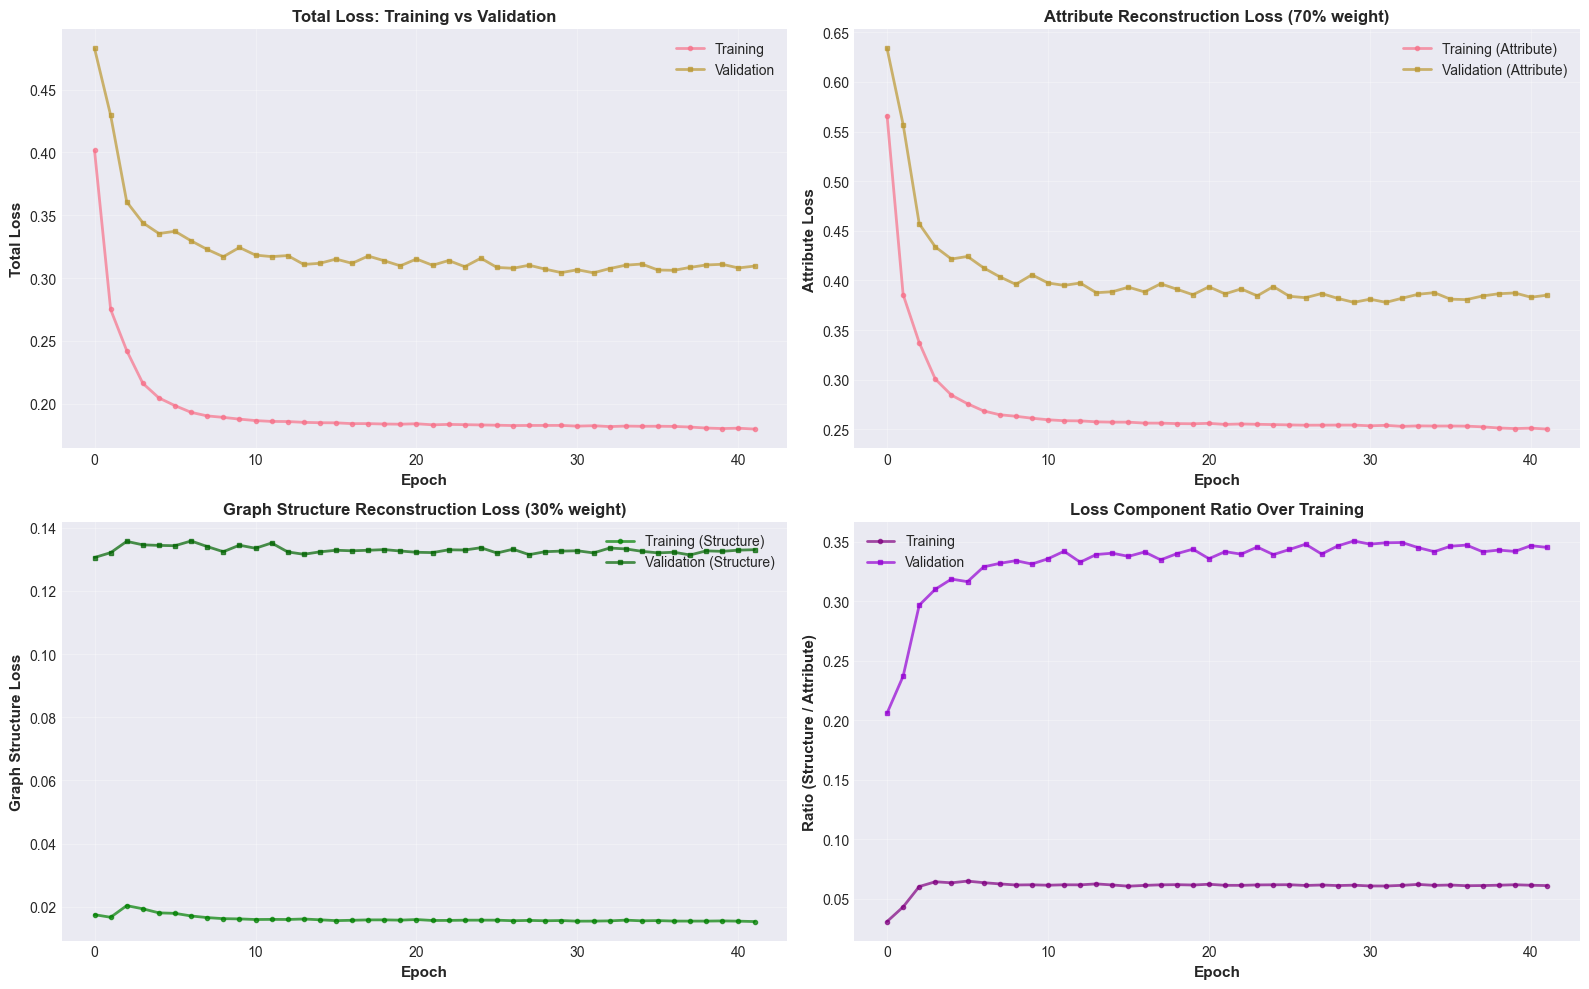


TRAINING SUMMARY: UNSUPERVISED GDN LOSS DECOMPOSITION

Attribute Loss (Sensor Value Reconstruction):
  Initial: 0.566186
  Final:   0.250353
  Reduction: 55.8%

Graph Structure Loss (Sensor Relationship Learning):
  Initial: 0.017474
  Final:   0.015298
  Reduction: 12.5%

Total Loss:
  Initial: 0.401573
  Final:   0.179837
  Reduction: 55.2%

Validation Performance:
  Best validation loss: 0.304195
  Best epoch: 31
  Final validation loss: 0.309562


In [477]:
# ============================================================================
# VISUALIZATION: Training Loss Decomposition
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Total Loss (Train vs Val)
axes[0, 0].plot(train_losses, label='Training', linewidth=2, marker='o', markersize=3, alpha=0.7)
axes[0, 0].plot(val_losses, label='Validation', linewidth=2, marker='s', markersize=3, alpha=0.7)
axes[0, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Total Loss', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Total Loss: Training vs Validation', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='upper right', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Attribute Loss Decomposition
axes[0, 1].plot(train_attr_losses, label='Training (Attribute)', linewidth=2, marker='o', markersize=3, alpha=0.7)
axes[0, 1].plot(val_attr_losses, label='Validation (Attribute)', linewidth=2, marker='s', markersize=3, alpha=0.7)
axes[0, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Attribute Loss', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Attribute Reconstruction Loss (70% weight)', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='upper right', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Graph Structure Loss Decomposition
axes[1, 0].plot(train_struct_losses, label='Training (Structure)', linewidth=2, marker='o', markersize=3, alpha=0.7, color='green')
axes[1, 0].plot(val_struct_losses, label='Validation (Structure)', linewidth=2, marker='s', markersize=3, alpha=0.7, color='darkgreen')
axes[1, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Graph Structure Loss', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Graph Structure Reconstruction Loss (30% weight)', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='upper right', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Loss Ratio (Structure / Attribute)
ratio_train = [s / (a + 1e-8) for s, a in zip(train_struct_losses, train_attr_losses)]
ratio_val = [s / (a + 1e-8) for s, a in zip(val_struct_losses, val_attr_losses)]

axes[1, 1].plot(ratio_train, label='Training', linewidth=2, marker='o', markersize=3, alpha=0.7, color='purple')
axes[1, 1].plot(ratio_val, label='Validation', linewidth=2, marker='s', markersize=3, alpha=0.7, color='darkviolet')
axes[1, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Ratio (Structure / Attribute)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Loss Component Ratio Over Training', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='best', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("TRAINING SUMMARY: UNSUPERVISED GDN LOSS DECOMPOSITION")
print("="*80)
print(f"\nAttribute Loss (Sensor Value Reconstruction):")
print(f"  Initial: {train_attr_losses[0]:.6f}")
print(f"  Final:   {train_attr_losses[-1]:.6f}")
print(f"  Reduction: {(1 - train_attr_losses[-1]/train_attr_losses[0])*100:.1f}%")

print(f"\nGraph Structure Loss (Sensor Relationship Learning):")
print(f"  Initial: {train_struct_losses[0]:.6f}")
print(f"  Final:   {train_struct_losses[-1]:.6f}")
print(f"  Reduction: {(1 - train_struct_losses[-1]/train_struct_losses[0])*100:.1f}%")

print(f"\nTotal Loss:")
print(f"  Initial: {train_losses[0]:.6f}")
print(f"  Final:   {train_losses[-1]:.6f}")
print(f"  Reduction: {(1 - train_losses[-1]/train_losses[0])*100:.1f}%")

print(f"\nValidation Performance:")
print(f"  Best validation loss: {min(val_losses):.6f}")
print(f"  Best epoch: {np.argmin(val_losses)}")
print(f"  Final validation loss: {val_losses[-1]:.6f}")
print("="*80)
